In [ ]:
import pandas as pd
import numpy as np

# Generate synthetic retail sales data
np.random.seed(42)
dates = pd.date_range(start='2018-01-01', periods=60, freq='ME')  # Use 'ME' instead of 'M'
sales = 100 + np.arange(60) * 2 + 10 * np.sin(2 * np.pi * np.arange(60) / 12) + np.random.normal(0, 5, 60)

# Create DataFrame
data = pd.DataFrame({'Date': dates, 'Sales': sales})
data.set_index('Date', inplace=True)

# Save to CSV (optional)
data.to_csv(r'C:\Users\sarum\OneDrive\Desktop\LEVEL 4\task 2\retail_sales_dataset.csv')

ADF Statistic: 1.1369198798726516
p-value: 0.9955197222350205
Data is not stationary. Applying differencing.


c:\Users\sarum\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sarum\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sarum\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sarum\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\sarum\AppData\Local\Programs\Python\Python312\L

ARIMA RMSE: 6.643862727294241
SARIMA RMSE: 6.615522314745156
RMSE Difference: 0.028340412549085592


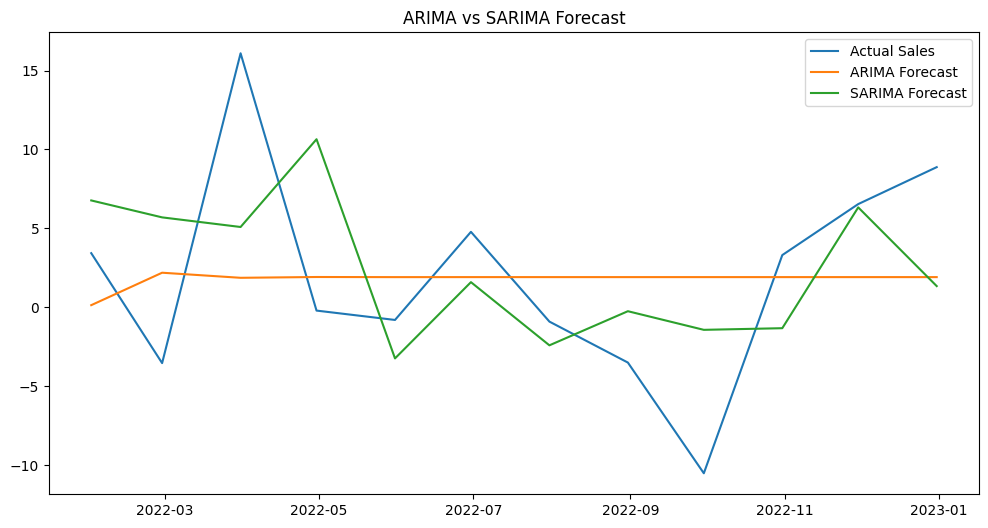

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv(r'C:\Users\sarum\OneDrive\Desktop\LEVEL 4\task 2\retail_sales_dataset.csv', parse_dates=['Date'], index_col='Date')

# Check for stationarity
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    return result[1] > 0.05

if check_stationarity(data['Sales']):
    print("Data is not stationary. Applying differencing.")
    data['Sales'] = data['Sales'].diff().dropna()

# Split data into train and test sets
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

# ARIMA Model
arima_model = ARIMA(train['Sales'], order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

# SARIMA Model
sarima_model = SARIMAX(train['Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit()
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Calculate RMSE
arima_rmse = np.sqrt(mean_squared_error(test['Sales'], arima_forecast))
sarima_rmse = np.sqrt(mean_squared_error(test['Sales'], sarima_forecast))

print(f"ARIMA RMSE: {arima_rmse}")
print(f"SARIMA RMSE: {sarima_rmse}")
print(f"RMSE Difference: {abs(arima_rmse - sarima_rmse)}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Sales'], label='Actual Sales')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.legend()
plt.title('ARIMA vs SARIMA Forecast')
plt.show()